In [95]:
import json, os
import cv2
import uuid
import tempfile
import subprocess
import numpy as np
from PIL import Image
from PIL import ImageOps
from matplotlib import pyplot as plt
from utils_image import resize_image,pad_image
from utils_dataset import CaptionRemover, crop_tight
# from visual import draw_system, draw_det
from abbreviation_detector import AbbreviationDetectorCPU, AbbreviationDetectorGPU

In [96]:
with open("./config_dataset_graph.json") as file:
    config_dataset_graph = json.load(file)
config_dataset_graph["image_size"] = [300, 300]

abbreviation_detector = AbbreviationDetectorGPU(config_dataset_graph, image_size = (300, 300), force_cpu = False)
images = ["/home/jovyan/rt-detr/output/test/pred/4.png",]
bonds_sizes = [100,]
caption_remover = CaptionRemover(force_cpu=True)   #删除化学结构图像中的标题

### 图片的前处理，resize到预设值，移除图片的caption，添加border(默认30)，二值化

In [97]:
pil_image = Image.open(images[0])
print(np.array(pil_image).shape)
pil_image = resize_image(
    pil_image, 
    (config_dataset_graph["image_size"][1], config_dataset_graph["image_size"][1]), 
    border_size = 30
)
print(np.array(pil_image).shape)
# Remove captions
image = caption_remover(pil_image)
print(image.shape)
# Remove borders
pil_image = Image.fromarray(image).convert('RGB')
pil_image = crop_tight(pil_image)
print(np.array(pil_image).shape)
# Resize, add small borders 
pil_image = resize_image(
    pil_image,
    (config_dataset_graph["image_size"][1], config_dataset_graph["image_size"][1]), 
    border_size = 30*3 
)
print(np.array(pil_image).shape)
# Threshold and convert to float
image = np.array(pil_image, dtype=np.float32)/255
# image[image > 0.6] = 1. 
# image[image != 1.] = 0.
# # th3 = cv2.adaptiveThreshold(image,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,\
# #  cv2.THRESH_BINARY,11,2)
# image = np.stack((image, )*3, axis=-1)

# image = np.array(image*255, dtype=np.uint8)

(300, 300, 3)
(300, 300)
(300, 300, 3)
(132, 221, 3)
(300, 300)


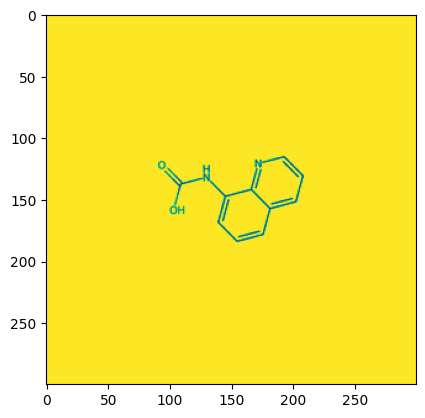

In [98]:
plt.imshow(image)

In [99]:
pil_image = Image.open("/home/jovyan/rt-detr/output/test/pred/4.png")
padded_image = pad_image(pil_image)

removed_image  = caption_remover(padded_image)
pil_image = Image.fromarray(removed_image).convert('RGB')
cropped_image = crop_tight(pil_image)
padded_image = pad_image(cropped_image)

image = np.array(padded_image, dtype=np.uint8)

# image = np.array(padded_image, dtype=np.float32)/255
# image[image > 0.6] = 1. 
# image[image != 1.] = 0.
ret2,image = cv2.threshold(image,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
# image = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 5)
image = np.stack((image, )*3, axis=-1)

# image = np.array(image*255, dtype=np.uint8)

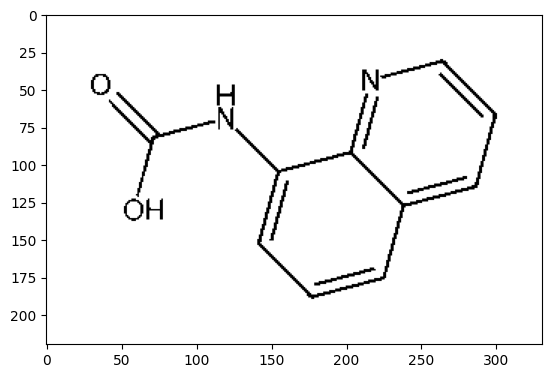

In [100]:
plt.imshow(image)

In [101]:
contour_method = cv2.RETR_EXTERNAL
contour_approx_mode = cv2.CHAIN_APPROX_SIMPLE
img = np.array(image[:,:,0])
t1 = img.copy().astype(np.uint8)
t2 = cv2.morphologyEx(t1, cv2.MORPH_GRADIENT, np.ones((2, 2)))
contours, _ = cv2.findContours(t2.astype(np.uint8), contour_method, contour_approx_mode)

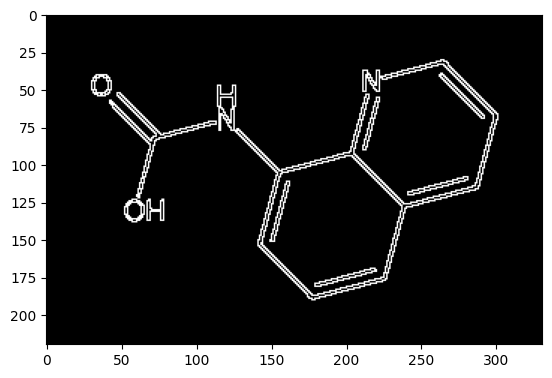

In [102]:
plt.imshow(t2, cmap="gray")

In [103]:
len(contours)

7

In [104]:
def draw_contours(image, contours):

    contour_img = np.zeros_like(image)
    for contour in contours:
        color = np.random.randint(0, 255, (3)).tolist()
        cv2.drawContours(contour_img, [contour], -1, color, 2)
    #     cv2.drawContours(contour_img, contours, -1, (0, 255, 0), 2)


    plt.figure(figsize=(10, 10))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB))
    plt.title('Contours')
    plt.axis('off')

    plt.show()

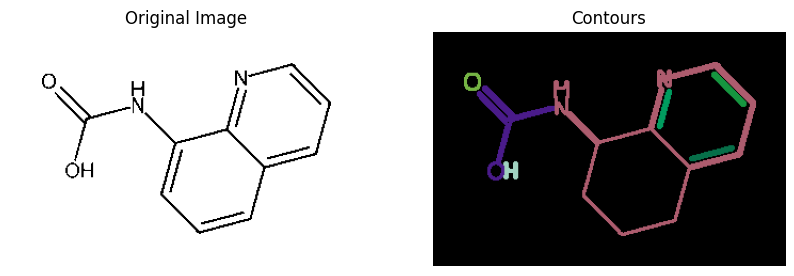

In [105]:
draw_contours(image, contours)

### This function cleans an image returning only the contours that represent letters.

In [106]:
def get_bond_size(input_path):
    with tempfile.TemporaryDirectory() as temp_dir:
        outfile_name = str(uuid.uuid4()) + '_molvec.json'
        outfile_path = os.path.join(temp_dir, outfile_name)
        cmd = ['java', "-Djava.awt.headless=true", 
               "-cp", "molvec.jar",
               "gov.nih.ncats.molvec.GetBoundingBoxes",
                input_path, outfile_path]
        
        p = subprocess.run(cmd, capture_output=True)
        code = p.returncode

        if code != 0:
            raise ValueError(
                "Subprocess call to molvec resulted in non-zero code: %s\nWith error: %s"
                % (str(code), p.stderr))
        try:
            molvec_res = json.load(open(outfile_path))
            ''' MeanLength:49.84035261181762
                LargestLength:66.05104086992124
                AverageLength:49.78049748239201
                MedianLength:73.39026187268128
            '''
            bond_size = molvec_res["Bondlentgh"] #["AverageLength"]
        except Exception as e:
            bond_size = 100
        
    if os.path.exists(temp_dir):
        raise IOError(
            "Temp directory cleanup failed.\n Directory %s still exists." %
            temp_dir)
    
    return bond_size

In [107]:
filtered_image = abbreviation_detector.filter_image(image, bond_size=80, pr_mode=3, kernel_size=2)

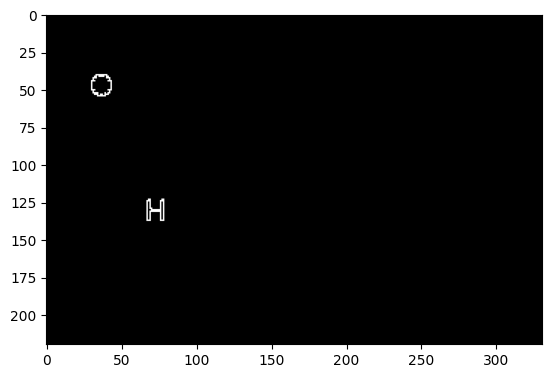

In [108]:
plt.imshow(filtered_image, cmap="gray")

In [109]:
abbreviation_detector.filtered_image = filtered_image
abbreviation_detector.image = image
abbreviation_detector.bond_size = 21

In [110]:
contour_method = cv2.RETR_EXTERNAL
contour_approx_mode = cv2.CHAIN_APPROX_SIMPLE
contours, _ = cv2.findContours(filtered_image.astype(np.uint8), contour_method, contour_approx_mode)

In [111]:
len(contours)

2

In [112]:
abbreviation_detector.set_letters_and_boxes()

In [113]:
letters = abbreviation_detector.letters
boxs = abbreviation_detector.boxes

In [126]:
letters[0].shape

(14, 11, 3)

In [114]:
len(letters), len(boxs)

(2, 2)

In [115]:
boxs[0]

array([[ 68, 122],
       [ 79, 122],
       [ 79, 138],
       [ 66, 138]])

In [116]:
boxs[0][0], boxs[0][2]

(array([ 68, 122]), array([ 79, 138]))

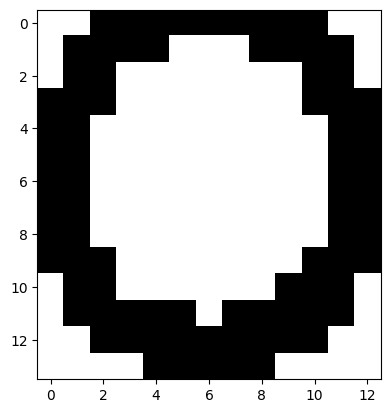

In [127]:
plt.imshow(letters[1])

In [118]:
image_org, texts, scores, boxes = abbreviation_detector.get_letter_predictions()

In [129]:
texts

[]

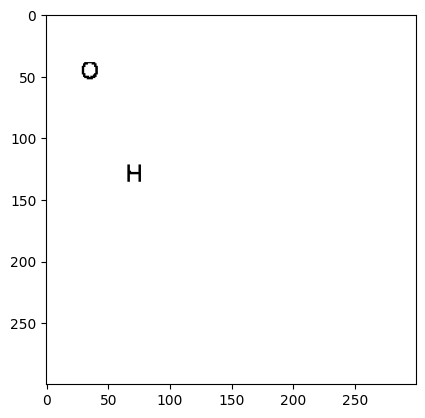

In [120]:
plt.imshow(image_org, cmap="gray")

In [16]:
def pad_image(image, border_size: int = 30, b="white"):
    
    width, height = image.size[0], image.size[1]
    if b == "black":
        background = Image.new('L', (width, height), (0))
    if b == "white":
        background = Image.new('L', (width, height), (255))
    offset = (0, 0)
    background.paste(image, offset)

    # Add a padding on image borders
    if b == "black":
        transformed_image = ImageOps.expand(background, border=border_size, fill='black')
    if b == "white":
        transformed_image = ImageOps.expand(background, border=border_size, fill='white')
        
    return transformed_image

In [33]:
def xywh_to_xyxy(x, y, w, h):
    ## x,y == ceneter coords or upper left coords?
    x1 = x
    y1 = y
    x2 = x + w
    y2 = y + h
    return x1, y1, x2, y2

In [120]:
def clean_image(img, alpha = 10,beta1=20,beta2=450,pr_mode=1,kernel_size=2):
    
    t1 =img.copy().astype(np.uint8)
    #preprocess the image so better contours can be detected
    if pr_mode ==1 :
        t1 = cv2.erode(t1,np.ones((kernel_size,kernel_size)))
    elif pr_mode == 2:
        t1 = cv2.morphologyEx(t1,cv2.MORPH_OPEN,np.ones((kernel_size,kernel_size)))
    else:
        t1 = cv2.morphologyEx(t1,cv2.MORPH_GRADIENT,np.ones((kernel_size,kernel_size)))

#  操作后会反转，测试，findContours 白底黑字检测到字符部分，反转后检测到的轮廓是整张图片      
#     t1 = t1 + 255
    
    #create canvas to draw contours on
    img = cv2.cvtColor(np.zeros_like(t1),cv2.COLOR_GRAY2RGB)
    
    #find contours
    contours, hierarchy = cv2.findContours(t1.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE )
    print(len(contours))
    cnts = []
    
    #function for box area calculation
    barea = lambda x: np.linalg.norm(x[0]-x[1])*np.linalg.norm(x[0]-x[3])
    #function for box side difference calculation
    bsd = lambda x: np.abs(np.linalg.norm(x[0]-x[1])-np.linalg.norm(x[0]-x[3]))

    #preprocess contours
    for cnt in contours:
        (x,y),radius = cv2.minEnclosingCircle(cnt)
        rect = cv2.minAreaRect(cnt)
        box = cv2.boxPoints(rect)
#         print(np.pi *radius**2, box, bsd(box))
#         if (beta1<np.pi *radius**2 < beta2) and bsd(box)<=alpha:
        cnts.append(cnt)
    
    print(len(cnts))
    wc = cv2.drawContours(img, cnts, -1, (0,255,0), 2)
    wc =  cv2.cvtColor(img,cv2.COLOR_RGB2GRAY)
    
    
    return cv2.bitwise_and(t1,t1,mask=wc)

In [ ]:
def get_letters(processed_img,scope=2):
    contours, hierarchy = cv2.findContours(processed_img.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE )
    letters = []
    for cts in contours:
        rect = cv2.minAreaRect(cts)
        box = cv2.boxPoints(rect)
        box = np.int0(box)
        W = rect[1][0]
        H = rect[1][1]
        Xs = [i[0] for i in box]
        Ys = [i[1] for i in box]
        x1 = min(Xs)
        x2 = max(Xs)
        y1 = min(Ys)
        y2 = max(Ys)

        rotated = False
        angle = rect[2]

        if angle < -45:
            angle+=90
            rotated = True

        center = (int((x1+x2)/2), int((y1+y2)/2))
        size = (int(scope*(x2-x1)),int(scope*(y2-y1)))
        M = cv2.getRotationMatrix2D((size[0]/2, size[1]/2), angle, 1.0)
        cropped = cv2.getRectSubPix(processed_img, size, center)    
        cropped = cv2.warpAffine(cropped, M, size)
        croppedW = W if not rotated else H 
        croppedH = H if not rotated else W
        croppedRotated = cv2.getRectSubPix(cropped, (int(croppedW*scope), int(croppedH*scope)), (size[0]/2, size[1]/2))
        croppedRotated = np.rot90(croppedRotated)

        #print(box)
        letters.append(croppedRotated)

    return letters